# 🧠 Comparação de Modelos para Predição de Pressão de Poços

Este notebook implementa e compara **3 modelos diferentes** para predição de séries temporais de pressão de poços de petróleo:

## **🎯 Modelos Implementados:**

### **1. 📈 Linear Regression (Baseline)**
- Usa regressão linear simples nos dados de treino
- Extrapola a tendência linear para o período de teste
- Modelo mais simples e interpretável

### **2. 🌊 Wave Regression (Sinusoidal)**
- Combina tendência linear + componente sinusoidal
- Adapta a regressão linear às flutuações do sinal original
- Captura padrões cíclicos nos dados

### **3. 🧠 LSTM Trend-Focused**
- Rede neural LSTM focada em seguir a tendência linear
- Usa features baseadas em tendência como entrada
- Combina capacidade de deep learning com foco na tendência

**Estratégia:**
- Treina com os primeiros 90% dos dados de cada poço
- Prediz os 10% restantes (dados futuros)
- Compara performance dos 3 modelos
- Avalia com métricas MAE, RMSE e MAPE

In [ ]:
# 📦 Instalação das dependências
!pip install -q tensorflow pandas numpy matplotlib scikit-learn PyWavelets scipy

## 🧭 1. Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn para regressão e métricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Scipy para otimização (wave regression)
from scipy.optimize import curve_fit

# TensorFlow/Keras para LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyWavelets para denoising (opcional)
import pywt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.test.is_gpu_available()}")
print(f"Bibliotecas carregadas com sucesso!")
print("✅ Pronto para comparar 3 modelos: Linear, Wave e LSTM")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow version: 2.19.0
GPU disponível: False
Bibliotecas carregadas com sucesso!
✅ Pronto para comparar 3 modelos: Linear, Wave e LSTM


## 📂 2. Configuração de caminhos e parâmetros

In [ ]:
# Configurações principais
DATA_PATH = "/content"
  # Pasta com os CSVs
PARAMETRO_ALVO = "TPT-P"  # Parâmetro de pressão a ser previsto
TRAIN_SPLIT = 0.9  # 90% para treino, 10% para teste

# Parâmetros para LSTM
SEQUENCE_LENGTH = 60        # Janela de entrada para LSTM
LSTM_UNITS = 64            # Unidades LSTM
DROPOUT_RATE = 0.2
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Parâmetros para Wave Regression
INITIAL_FREQUENCY = 1/365  # Frequência inicial (anual)
INITIAL_AMPLITUDE = 0.1    # Amplitude inicial (10% da pressão média)

# Parâmetros gerais
MIN_DATA_POINTS = 200      # Mínimo de pontos para processar um poço
SMOOTHING_WINDOW = 15      # Janela para suavização

print(f"Configurações dos 3 Modelos:")
print(f"=" * 50)
print(f"📊 Dados:")
print(f"   - Parâmetro alvo: {PARAMETRO_ALVO}")
print(f"   - Split treino/teste: {TRAIN_SPLIT:.0%}/{1-TRAIN_SPLIT:.0%}")
print(f"   - Mínimo de pontos: {MIN_DATA_POINTS}")
print(f"")
print(f"📈 Modelo 1 - Linear Regression:")
print(f"   - Método: sklearn.LinearRegression")
print(f"   - Features: tempo (índice linear)")
print(f"")
print(f"🌊 Modelo 2 - Wave Regression:")
print(f"   - Método: Tendência + Componente Sinusoidal")
print(f"   - Freq inicial: {INITIAL_FREQUENCY:.6f} (anual)")
print(f"   - Amplitude inicial: {INITIAL_AMPLITUDE:.1%}")
print(f"")
print(f"🧠 Modelo 3 - LSTM Trend-Focused:")
print(f"   - Sequência: {SEQUENCE_LENGTH} pontos")
print(f"   - Unidades LSTM: {LSTM_UNITS}")
print(f"   - Épocas: {EPOCHS}")
print(f"   - Features: trend-based")

Configurações dos 3 Modelos:
📊 Dados:
   - Parâmetro alvo: TPT-P
   - Split treino/teste: 90%/10%
   - Mínimo de pontos: 200

📈 Modelo 1 - Linear Regression:
   - Método: sklearn.LinearRegression
   - Features: tempo (índice linear)

🌊 Modelo 2 - Wave Regression:
   - Método: Tendência + Componente Sinusoidal
   - Freq inicial: 0.002740 (anual)
   - Amplitude inicial: 10.0%

🧠 Modelo 3 - LSTM Trend-Focused:
   - Sequência: 60 pontos
   - Unidades LSTM: 64
   - Épocas: 100
   - Features: trend-based


## 🔧 3. Funções auxiliares

In [ ]:
def preprocess_data_simple(file_path):
    """
    Pré-processa os dados de forma simples para os 3 modelos
    """
    try:
        # Ler o CSV
        df_raw = pd.read_csv(file_path)
        df_raw.columns = df_raw.columns.map(lambda x: x.strip() if isinstance(x, str) else x)

        # Identificar coluna de data
        date_col = next((c for c in df_raw.columns if "date" in c.lower() or "time" in c.lower()), None)
        if date_col is None:
            raise ValueError(f"Não encontrei coluna de data em {file_path}")

        # Converter data
        df_raw[date_col] = pd.to_datetime(df_raw[date_col], errors="coerce")

        # Identificar coluna do parâmetro alvo
        param_col = next((c for c in df_raw.columns if PARAMETRO_ALVO.lower() in c.lower()), None)
        if param_col is None:
            raise ValueError(f"Não encontrei coluna {PARAMETRO_ALVO} em {file_path}")

        # Converter parâmetro para numérico
        df_raw[param_col] = pd.to_numeric(df_raw[param_col], errors="coerce")

        # Limpar dados
        df_clean = df_raw.dropna(subset=[date_col, param_col]).query(f"`{param_col}` > 0")

        if len(df_clean) < MIN_DATA_POINTS:
            raise ValueError(f"Poucos dados válidos em {file_path}")

        # Remover outliers extremos (percentis 1% - 99%)
        q_low, q_high = df_clean[param_col].quantile([0.01, 0.99])
        df_clean = df_clean[df_clean[param_col].between(q_low, q_high)]

        # Reamostragem diária com mediana
        df_daily = (df_clean.set_index(date_col)[param_col]
                   .resample("1D")
                   .median()
                   .interpolate("linear")
                   .dropna())

        # Suavização leve
        df_smoothed = df_daily.rolling(window=SMOOTHING_WINDOW, center=True).mean()
        df_smoothed = df_smoothed.fillna(method='bfill').fillna(method='ffill')

        print(f"   Processados: {len(df_smoothed)} pontos diários")

        return df_smoothed

    except Exception as e:
        print(f"Erro ao processar {file_path}: {e}")
        return None

# ============= MODELO 1: LINEAR REGRESSION =============
def linear_regression_model(train_data, test_length):
    """
    Modelo 1: Regressão Linear Simples
    """
    # Preparar dados para regressão
    X_train = np.arange(len(train_data)).reshape(-1, 1)
    y_train = train_data.values

    # Treinar modelo linear
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Gerar predições para período de teste
    X_test = np.arange(len(train_data), len(train_data) + test_length).reshape(-1, 1)
    y_pred = model.predict(X_test)

    return y_pred, model.coef_[0], model.intercept_

# ============= MODELO 2: WAVE REGRESSION =============
def wave_function(t, a, b, c, d, e):
    """
    Função combinada: tendência linear + componente sinusoidal
    a, b: parâmetros da tendência linear (a*t + b)
    c, d, e: parâmetros da onda (c * sin(d*t + e))
    """
    return a * t + b + c * np.sin(d * t + e)

def wave_regression_model(train_data, test_length):
    """
    Modelo 2: Regressão com Componente Sinusoidal
    """
    # Preparar dados
    t_train = np.arange(len(train_data))
    y_train = train_data.values

    # Estimativas iniciais dos parâmetros
    # Linear trend
    slope = (y_train[-1] - y_train[0]) / len(y_train)
    intercept = y_train[0]

    # Wave components
    amplitude = np.std(y_train) * INITIAL_AMPLITUDE
    frequency = INITIAL_FREQUENCY * 2 * np.pi
    phase = 0

    initial_guess = [slope, intercept, amplitude, frequency, phase]

    try:
        # Ajustar modelo com curve_fit
        popt, _ = curve_fit(wave_function, t_train, y_train, p0=initial_guess, maxfev=5000)

        # Gerar predições
        t_test = np.arange(len(train_data), len(train_data) + test_length)
        y_pred = wave_function(t_test, *popt)

        return y_pred, popt

    except Exception as e:
        print(f"   Aviso: Wave regression falhou, usando linear: {e}")
        # Fallback para linear
        y_pred_linear, slope, intercept = linear_regression_model(train_data, test_length)
        popt = [slope, intercept, 0, 0, 0]  # sem componente wave
        return y_pred_linear, popt

# ============= MODELO 3: LSTM TREND-FOCUSED =============
def create_trend_sequences(data, sequence_length):
    """
    Cria sequências focadas na tendência para LSTM
    """
    # Calcular tendência local usando regressão linear em janelas
    trend_data = []

    for i in range(len(data)):
        start_idx = max(0, i - sequence_length//2)
        end_idx = min(len(data), i + sequence_length//2 + 1)

        if end_idx - start_idx > 5:  # mínimo 5 pontos para regressão
            window_data = data[start_idx:end_idx]
            X_window = np.arange(len(window_data)).reshape(-1, 1)

            reg = LinearRegression()
            reg.fit(X_window, window_data)
            trend_value = reg.predict([[len(window_data)//2]])[0]
            trend_data.append(trend_value)
        else:
            trend_data.append(data[i])

    trend_data = np.array(trend_data)

    # Criar sequências X, y
    X, y = [], []
    for i in range(sequence_length, len(trend_data)):
        X.append(trend_data[i-sequence_length:i])
        y.append(data[i])  # Predizer valor real, não tendência

    return np.array(X), np.array(y)

def build_trend_lstm_model(sequence_length):
    """
    Constrói modelo LSTM focado em tendências
    """
    model = Sequential([
        LSTM(LSTM_UNITS, return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS//2, return_sequences=False),
        Dropout(DROPOUT_RATE),
        Dense(LSTM_UNITS//4, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mse',
        metrics=['mae']
    )

    return model

def lstm_trend_model(train_data, test_length):
    """
    Modelo 3: LSTM Focado em Tendência
    """
    try:
        # Normalizar dados
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1)).flatten()

        # Criar sequências baseadas em tendência
        X, y = create_trend_sequences(train_scaled, SEQUENCE_LENGTH)

        if len(X) < 10:  # Dados insuficientes
            raise ValueError("Dados insuficientes para LSTM")

        # Reshape para LSTM
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Construir e treinar modelo
        model = build_trend_lstm_model(SEQUENCE_LENGTH)

        # Callbacks
        early_stopping = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)

        # Treinar
        model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE,
                 callbacks=[early_stopping], verbose=0)

        # Gerar predições futuras
        predictions = []
        current_sequence = train_scaled[-SEQUENCE_LENGTH:]

        for _ in range(test_length):
            # Preparar entrada
            input_data = current_sequence.reshape(1, SEQUENCE_LENGTH, 1)

            # Predizer próximo ponto
            next_pred = model.predict(input_data, verbose=0)[0, 0]
            predictions.append(next_pred)

            # Atualizar sequência
            current_sequence = np.append(current_sequence[1:], next_pred)

        # Desnormalizar predições
        predictions = np.array(predictions).reshape(-1, 1)
        y_pred = scaler.inverse_transform(predictions).flatten()

        return y_pred, model

    except Exception as e:
        print(f"   Aviso: LSTM falhou, usando linear: {e}")
        # Fallback para linear
        y_pred_linear, slope, intercept = linear_regression_model(train_data, test_length)
        return y_pred_linear, None

def calculate_metrics(y_true, y_pred):
    """
    Calcula métricas de avaliação
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (Mean Absolute Percentage Error)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print("✅ Funções dos 3 modelos definidas:")
print("   📈 1. Linear Regression - sklearn.LinearRegression")
print("   🌊 2. Wave Regression - Linear + Sinusoidal")
print("   🧠 3. LSTM Trend-Focused - Trend-aware LSTM")

✅ Funções dos 3 modelos definidas:
   📈 1. Linear Regression - sklearn.LinearRegression
   🌊 2. Wave Regression - Linear + Sinusoidal
   🧠 3. LSTM Trend-Focused - Trend-aware LSTM


## 📊 4. Processamento de todos os poços

In [ ]:
import glob, os

csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
print(f"Encontrados {len(csv_files)} arquivos CSV:")
for f in csv_files:
    print("  -", os.path.basename(f))


Encontrados 6 arquivos CSV:
  - SPH-8.csv
  - SPH-6.csv
  - SPS-77.csv
  - SPH-2.csv
  - LL-22.csv
  - LL-11.csv


In [ ]:
# Listar todos os arquivos CSV
csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
print(f"Encontrados {len(csv_files)} arquivos CSV:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

# Dicionário para armazenar resultados
results = {}

print("\n" + "="*60)
print("🚀 INICIANDO PROCESSAMENTO DOS POÇOS")
print("="*60)

Encontrados 6 arquivos CSV:
  - SPH-8.csv
  - SPH-6.csv
  - SPS-77.csv
  - SPH-2.csv
  - LL-22.csv
  - LL-11.csv

🚀 INICIANDO PROCESSAMENTO DOS POÇOS


   Processados: 1868 pontos diários


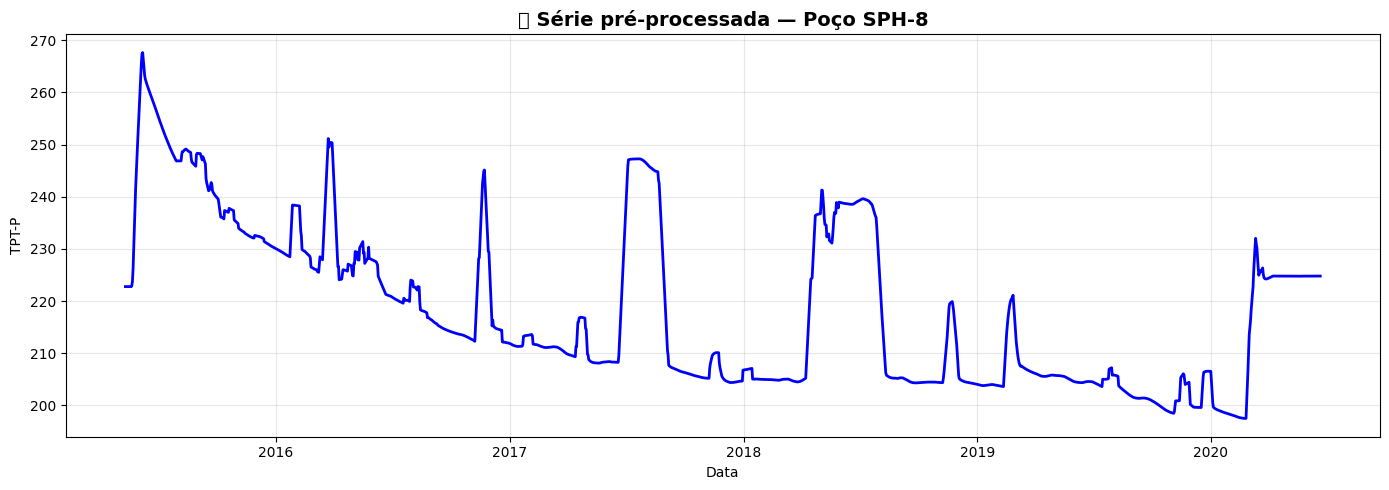

   Processados: 1782 pontos diários


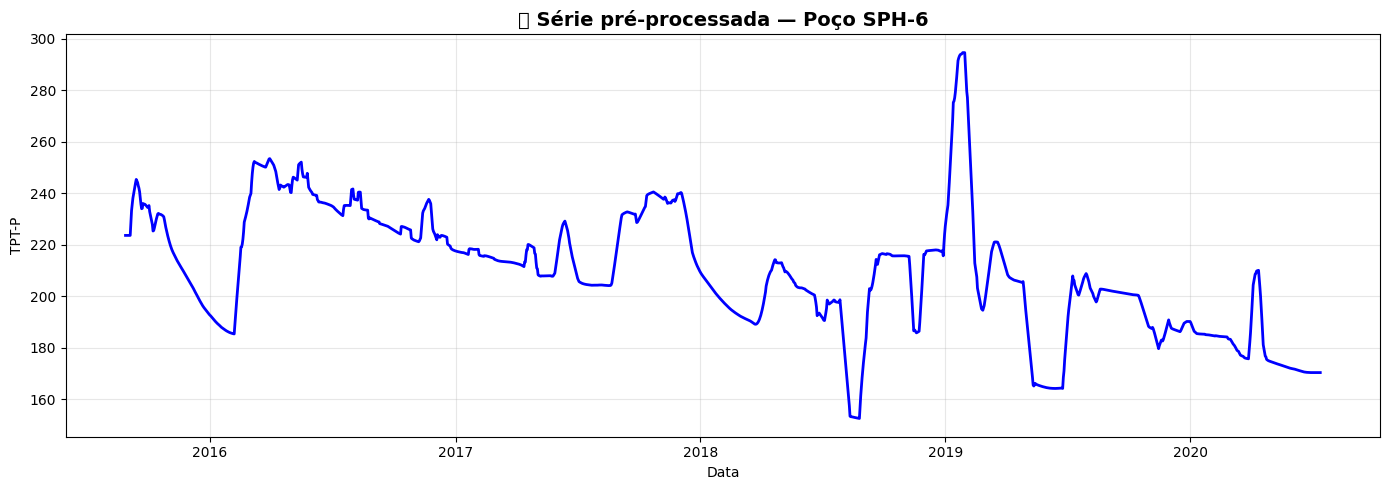

   Processados: 2324 pontos diários


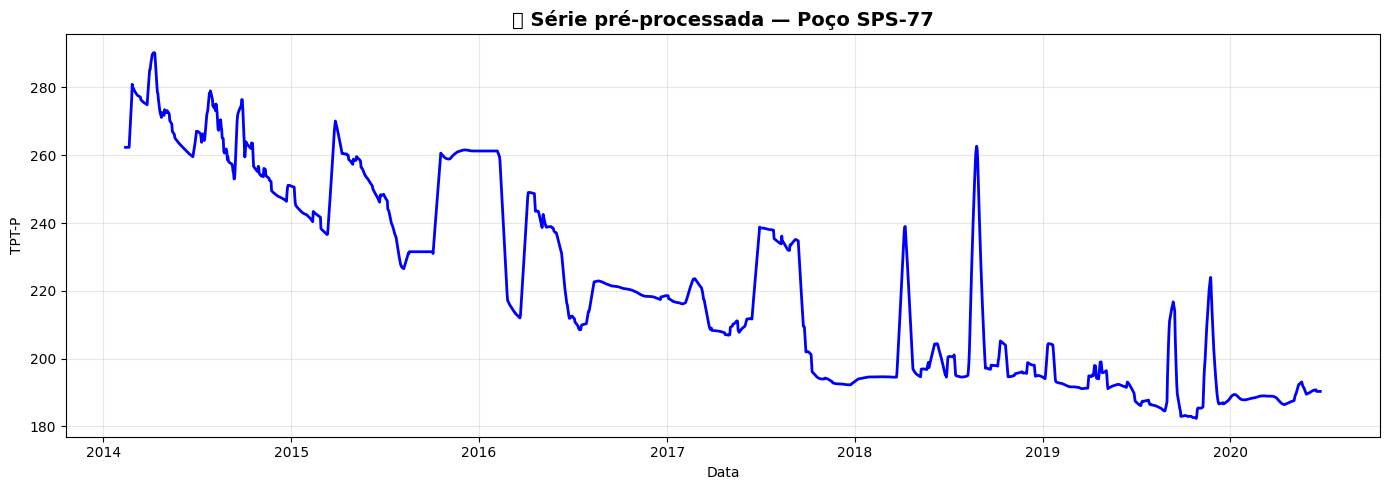

   Processados: 1827 pontos diários


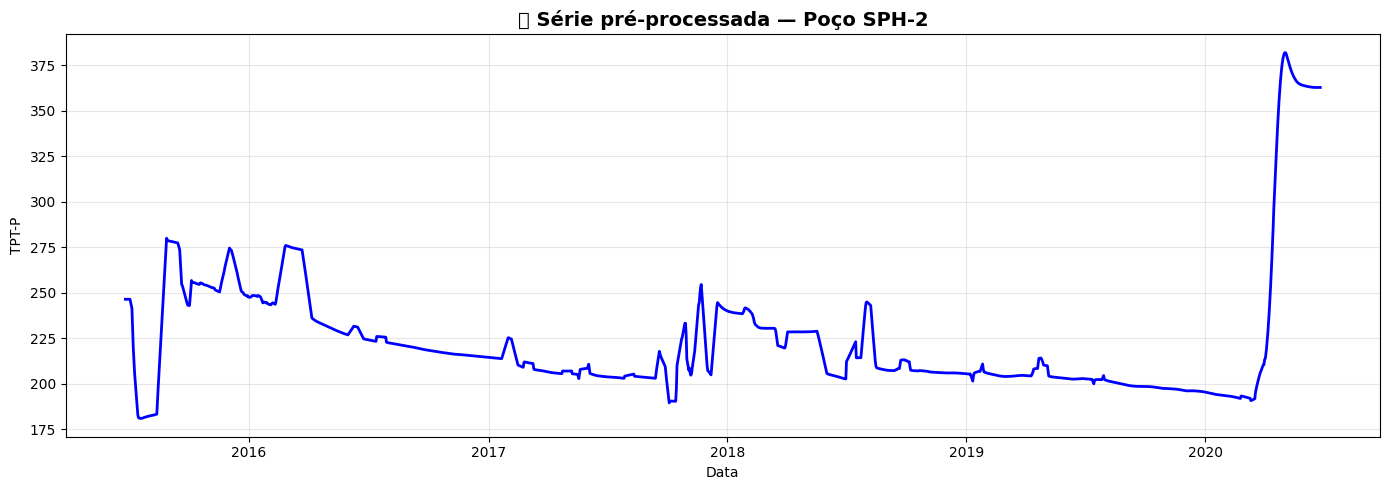

   Processados: 2259 pontos diários


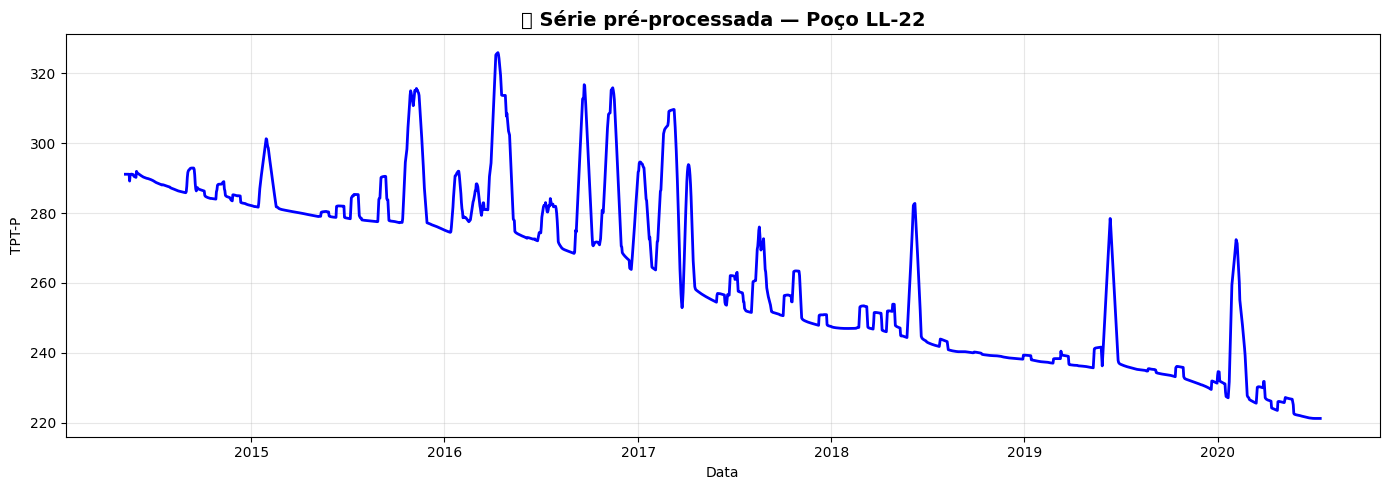

   Processados: 2587 pontos diários


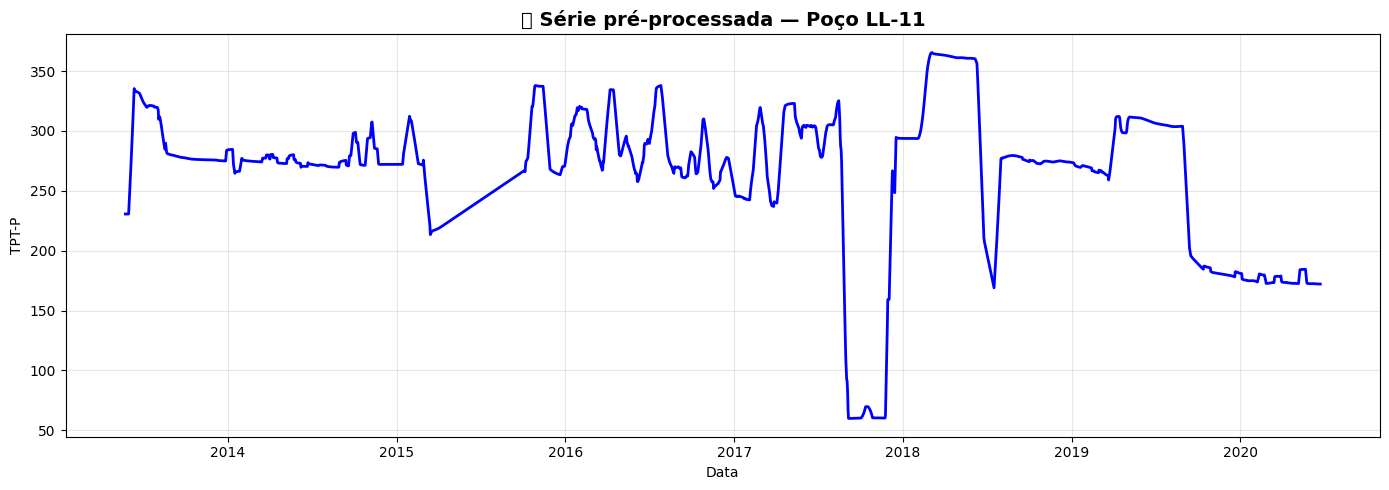

In [ ]:
# ==============================================
# 📈 Visualização dos dados pré-processados (1 gráfico por poço)
# ==============================================

for file_path in csv_files:
    # Nome do poço (sem extensão)
    well_name = os.path.basename(file_path).replace('.csv', '')

    # Pré-processar dados
    df_smoothed = preprocess_data_simple(file_path)

    if df_smoothed is None or len(df_smoothed) == 0:
        print(f"⚠️ Poço {well_name} — dados insuficientes ou erro no pré-processamento.")
        continue

    # Criar figura individual
    plt.figure(figsize=(14, 5))
    plt.plot(df_smoothed.index, df_smoothed.values, color='blue', linewidth=2)
    plt.title(f"📊 Série pré-processada — Poço {well_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Data")
    plt.ylabel(PARAMETRO_ALVO)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Loop principal - Comparação dos 3 Modelos
print("\n" + "="*80)
print("🚀 COMPARAÇÃO DE 3 MODELOS PARA PREDIÇÃO DE PRESSÃO")
print("="*80)

# Estruturas para armazenar resultados
results = {}
model_comparison = {
    'Linear': [],
    'Wave': [],
    'LSTM': []
}

print("\n📊 PROCESSAMENTO DE TODOS OS POÇOS")
print("-" * 60)

# Lista global para armazenar previsões de todos os poços
all_preds = []


# Processar todos os poços
for i, file_path in enumerate(csv_files, 1):
    well_name = os.path.basename(file_path).replace('.csv', '')
    print(f"\n📍 [{i}/{len(csv_files)}] Processando: {well_name}")
    print("-" * 40)

    # 1. Pré-processamento
    print("🔄 Pré-processando dados...")
    data = preprocess_data_simple(file_path)

    if data is None or len(data) < MIN_DATA_POINTS:
        print(f"❌ Dados insuficientes para {well_name}")
        continue

    # 2. Divisão treino/teste
    split_idx = int(len(data) * TRAIN_SPLIT)
    train_data = data.iloc[:split_idx]
    test_data = data.iloc[split_idx:]

    print(f"📊 Treino: {len(train_data)} pontos | Teste: {len(test_data)} pontos")

    if len(test_data) < 5:
        print(f"❌ Período de teste muito pequeno para {well_name}")
        continue

    # Preparar estrutura de resultados
    well_results = {
        'data': data,
        'train_data': train_data,
        'test_data': test_data,
        'split_idx': split_idx,
        'predictions': {},
        'metrics': {},
        'models': {}
    }

    # ============= MODELO 1: LINEAR REGRESSION =============
    print("📈 Modelo 1: Linear Regression...")
    try:
        y_pred_linear, slope, intercept = linear_regression_model(train_data, len(test_data))
        metrics_linear = calculate_metrics(test_data.values, y_pred_linear)

        well_results['predictions']['Linear'] = y_pred_linear
        well_results['metrics']['Linear'] = metrics_linear
        well_results['models']['Linear'] = {'slope': slope, 'intercept': intercept}
        model_comparison['Linear'].append(metrics_linear['MAE'])

        print(f"   ✅ MAE: {metrics_linear['MAE']:.4f} | MAPE: {metrics_linear['MAPE']:.2f}%")

    except Exception as e:
        print(f"   ❌ Erro no Linear: {e}")
        well_results['predictions']['Linear'] = None
        well_results['metrics']['Linear'] = None

    # ============= MODELO 2: WAVE REGRESSION =============
    print("🌊 Modelo 2: Wave Regression...")
    try:
        y_pred_wave, wave_params = wave_regression_model(train_data, len(test_data))
        metrics_wave = calculate_metrics(test_data.values, y_pred_wave)

        well_results['predictions']['Wave'] = y_pred_wave
        well_results['metrics']['Wave'] = metrics_wave
        well_results['models']['Wave'] = {'params': wave_params}
        model_comparison['Wave'].append(metrics_wave['MAE'])

        print(f"   ✅ MAE: {metrics_wave['MAE']:.4f} | MAPE: {metrics_wave['MAPE']:.2f}%")

        # Info sobre parâmetros da onda
        slope, intercept, amplitude, frequency, phase = wave_params
        print(f"   📊 Trend: {slope:.6f} | Wave amp: {amplitude:.4f}")

    except Exception as e:
        print(f"   ❌ Erro no Wave: {e}")
        well_results['predictions']['Wave'] = None
        well_results['metrics']['Wave'] = None

    # ============= MODELO 3: LSTM TREND-FOCUSED =============
    print("🧠 Modelo 3: LSTM Trend-Focused...")
    try:
        y_pred_lstm, lstm_model = lstm_trend_model(train_data, len(test_data))
        metrics_lstm = calculate_metrics(test_data.values, y_pred_lstm)

        well_results['predictions']['LSTM'] = y_pred_lstm
        well_results['metrics']['LSTM'] = metrics_lstm
        well_results['models']['LSTM'] = lstm_model
        model_comparison['LSTM'].append(metrics_lstm['MAE'])

        print(f"   ✅ MAE: {metrics_lstm['MAE']:.4f} | MAPE: {metrics_lstm['MAPE']:.2f}%")

    except Exception as e:
        print(f"   ❌ Erro no LSTM: {e}")
        well_results['predictions']['LSTM'] = None
        well_results['metrics']['LSTM'] = None

    # Salvar resultados do poço
    results[well_name] = well_results

    # Comparação rápida dos modelos para este poço
    valid_models = [(name, metrics) for name, metrics in well_results['metrics'].items()
                   if metrics is not None]

    if valid_models:
        best_model = min(valid_models, key=lambda x: x[1]['MAE'])
        print(f"🏆 Melhor modelo para {well_name}: {best_model[0]} (MAE: {best_model[1]['MAE']:.4f})")
    # Armazenar previsões para este poço
    df_temp = pd.DataFrame({
        "poco": well_name,
        "dates": test_data.index,            # datas do período de teste
        "y_true": test_data.values,          # valores reais
        "yhat_linear": y_pred_linear,
        "yhat_wave": y_pred_wave,
        "yhat_lstm": y_pred_lstm
    })
    all_preds.append(df_temp)

print("\n" + "="*80)
print(f"🎉 PROCESSAMENTO CONCLUÍDO!")
print(f"   Poços processados: {len(results)}")
print(f"   Modelos comparados: 3 (Linear, Wave, LSTM)")
print("="*80)

# Resumo geral dos modelos
print(f"\n📊 RESUMO GERAL DAS PERFORMANCES:")
print("-" * 50)

for model_name, mae_values in model_comparison.items():
    if mae_values:
        avg_mae = np.mean(mae_values)
        std_mae = np.std(mae_values)
        min_mae = np.min(mae_values)
        max_mae = np.max(mae_values)

        print(f"{model_name}:")
        print(f"   MAE médio: {avg_mae:.4f} ± {std_mae:.4f}")
        print(f"   MAE range: {min_mae:.4f} - {max_mae:.4f}")
        print(f"   Poços válidos: {len(mae_values)}")
        print()

# Determinar modelo geral mais eficaz
avg_maes = {name: np.mean(values) for name, values in model_comparison.items() if values}
if avg_maes:
    best_overall = min(avg_maes.items(), key=lambda x: x[1])
    print(f"🏆 MELHOR MODELO GERAL: {best_overall[0]} (MAE médio: {best_overall[1]:.4f})")


🚀 COMPARAÇÃO DE 3 MODELOS PARA PREDIÇÃO DE PRESSÃO

📊 PROCESSAMENTO DE TODOS OS POÇOS
------------------------------------------------------------

📍 [1/6] Processando: SPH-2
----------------------------------------
🔄 Pré-processando dados...
   Processados: 1827 pontos diários
📊 Treino: 1644 pontos | Teste: 183 pontos
📈 Modelo 1: Linear Regression...
   ✅ MAE: 72.0714 | MAPE: 20.73%
🌊 Modelo 2: Wave Regression...
   ✅ MAE: 74.1724 | MAPE: 21.64%
   📊 Trend: -0.026121 | Wave amp: 4.2094
🧠 Modelo 3: LSTM Trend-Focused...
   ✅ MAE: 70.7407 | MAPE: 20.31%
🏆 Melhor modelo para SPH-2: LSTM (MAE: 70.7407)

📍 [2/6] Processando: SPS-77
----------------------------------------
🔄 Pré-processando dados...
   Processados: 2324 pontos diários
📊 Treino: 2091 pontos | Teste: 233 pontos
📈 Modelo 1: Linear Regression...
   ✅ MAE: 14.2098 | MAPE: 7.35%
🌊 Modelo 2: Wave Regression...
   ✅ MAE: 8.6894 | MAPE: 4.44%
   📊 Trend: -0.040176 | Wave amp: 6.1137
🧠 Modelo 3: LSTM Trend-Focused...
   ✅ MAE: 34.03


📊 CRIANDO VISUALIZAÇÕES COMPARATIVAS

📈 Criando gráfico de performance por poço...


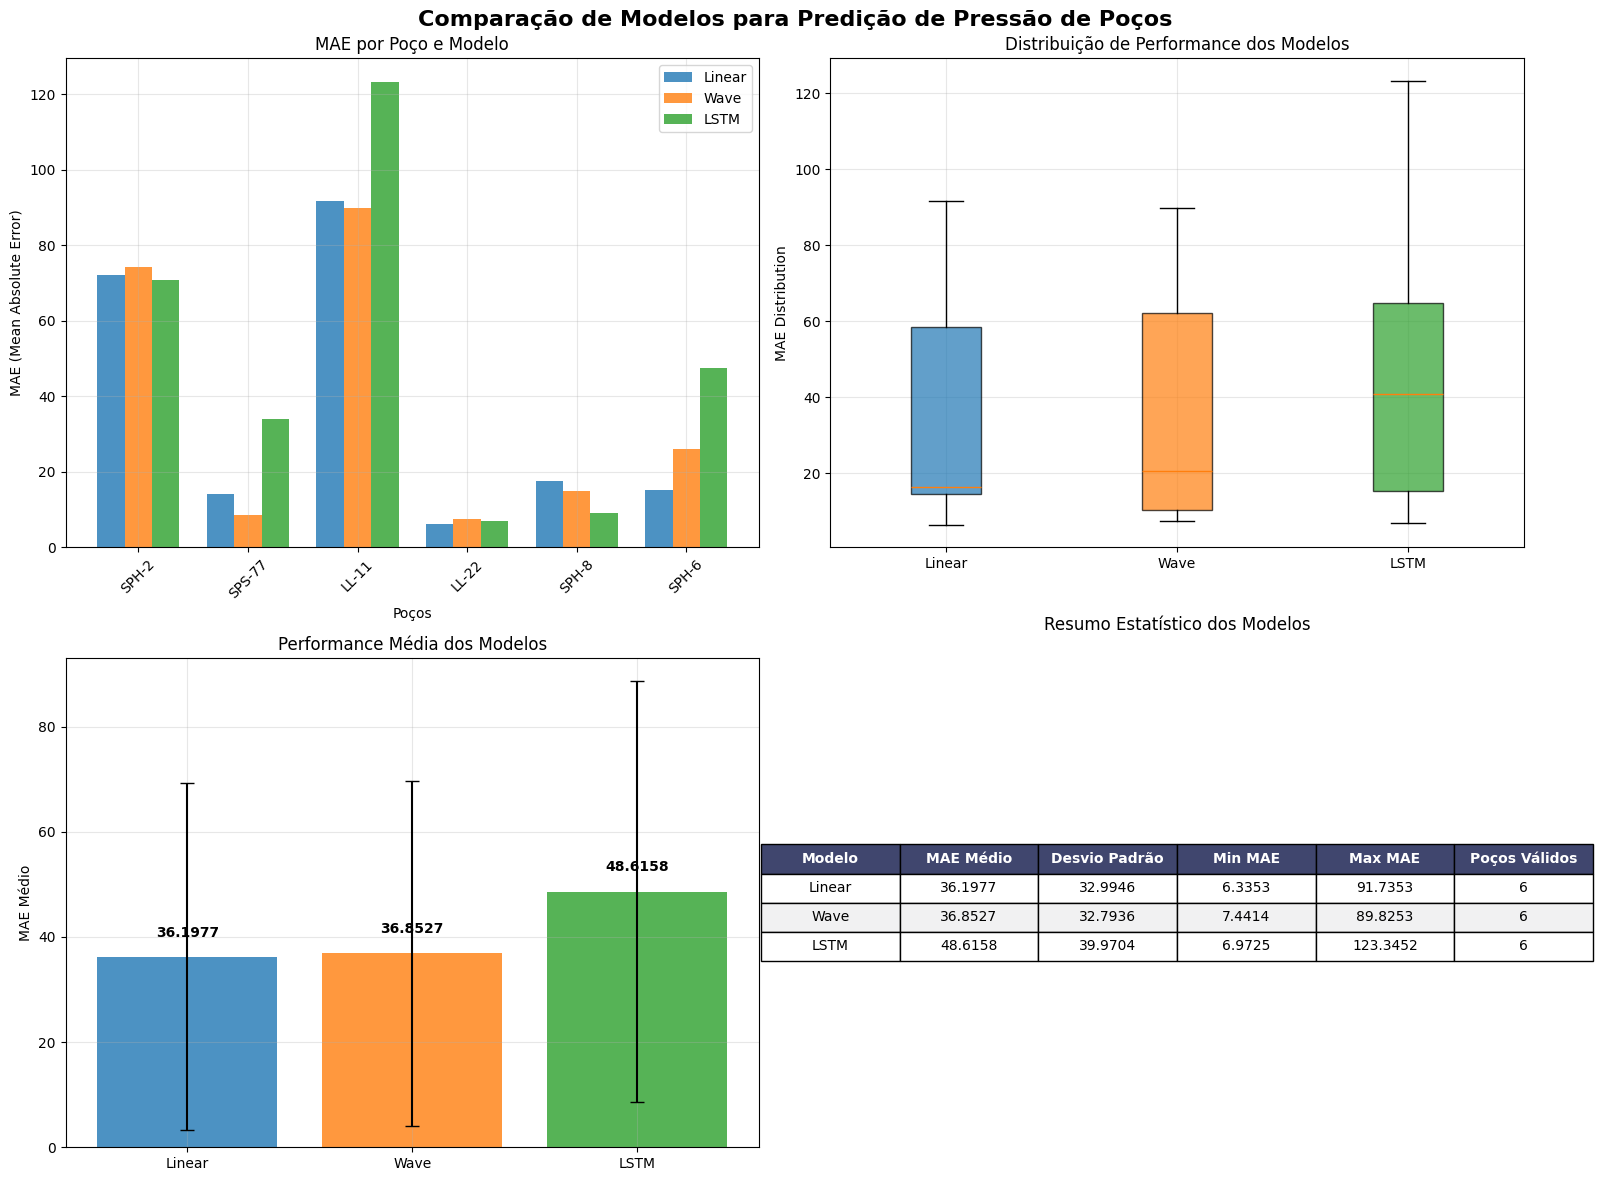

✅ Gráfico geral criado com sucesso!

📊 Criando gráficos individuais para os primeiros poços...
   📈 Plotando SPH-2...


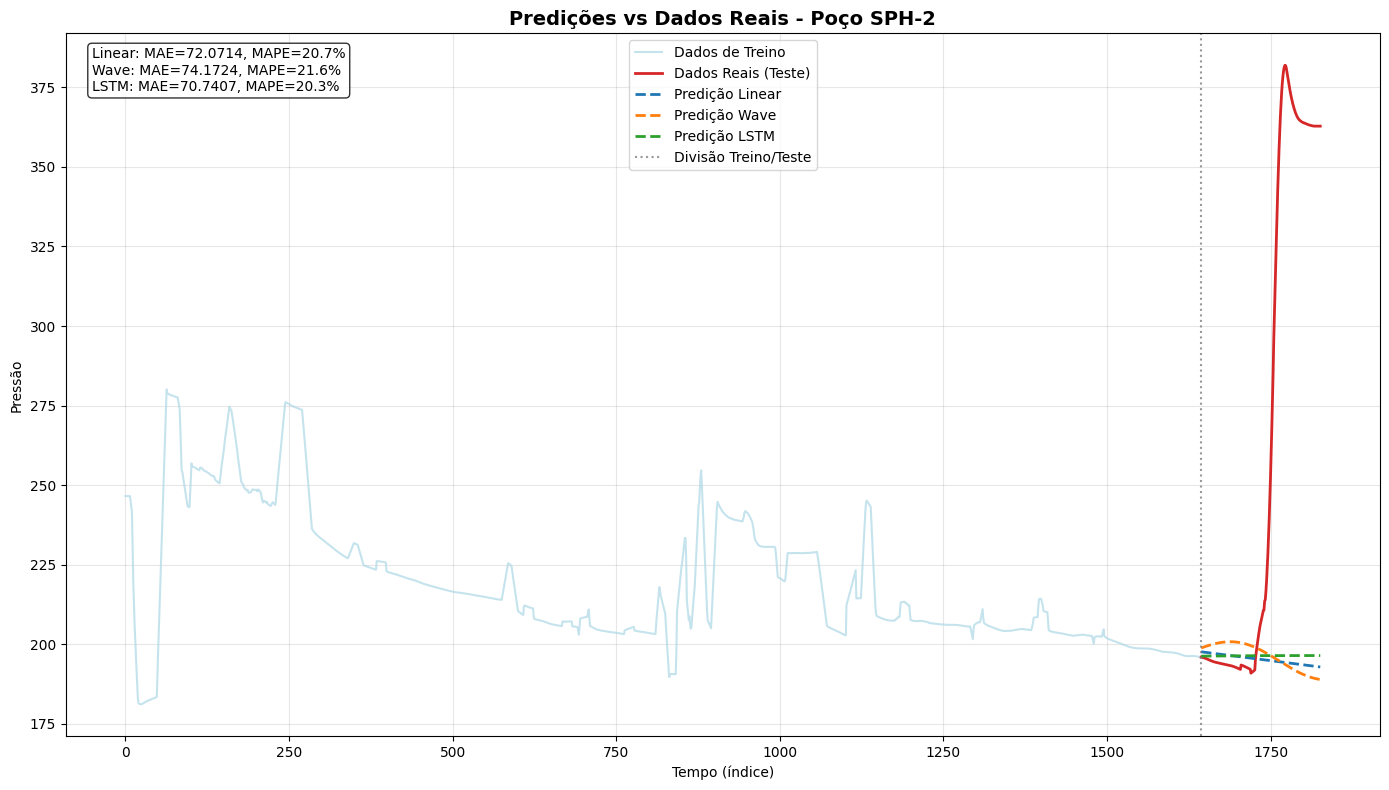

   📈 Plotando SPS-77...


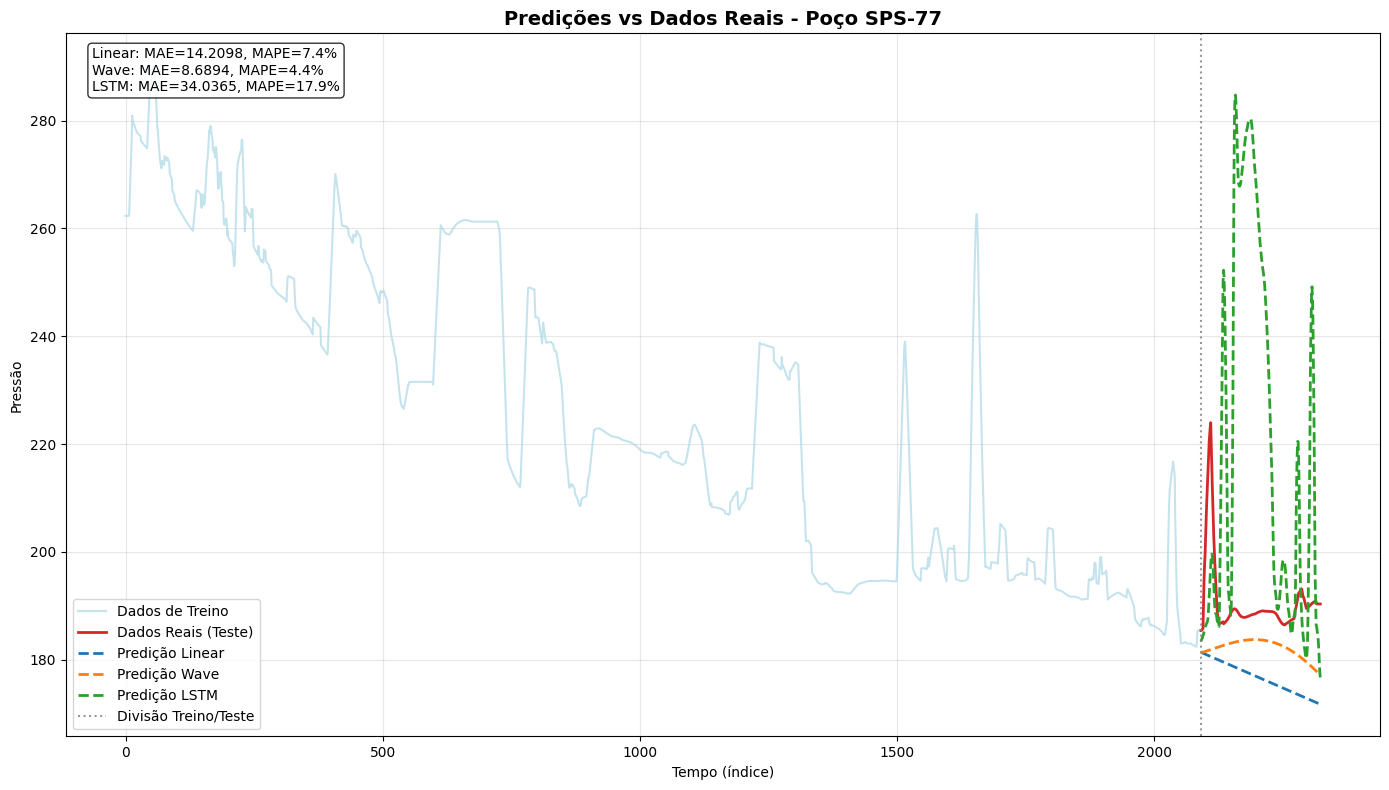

   📈 Plotando LL-11...


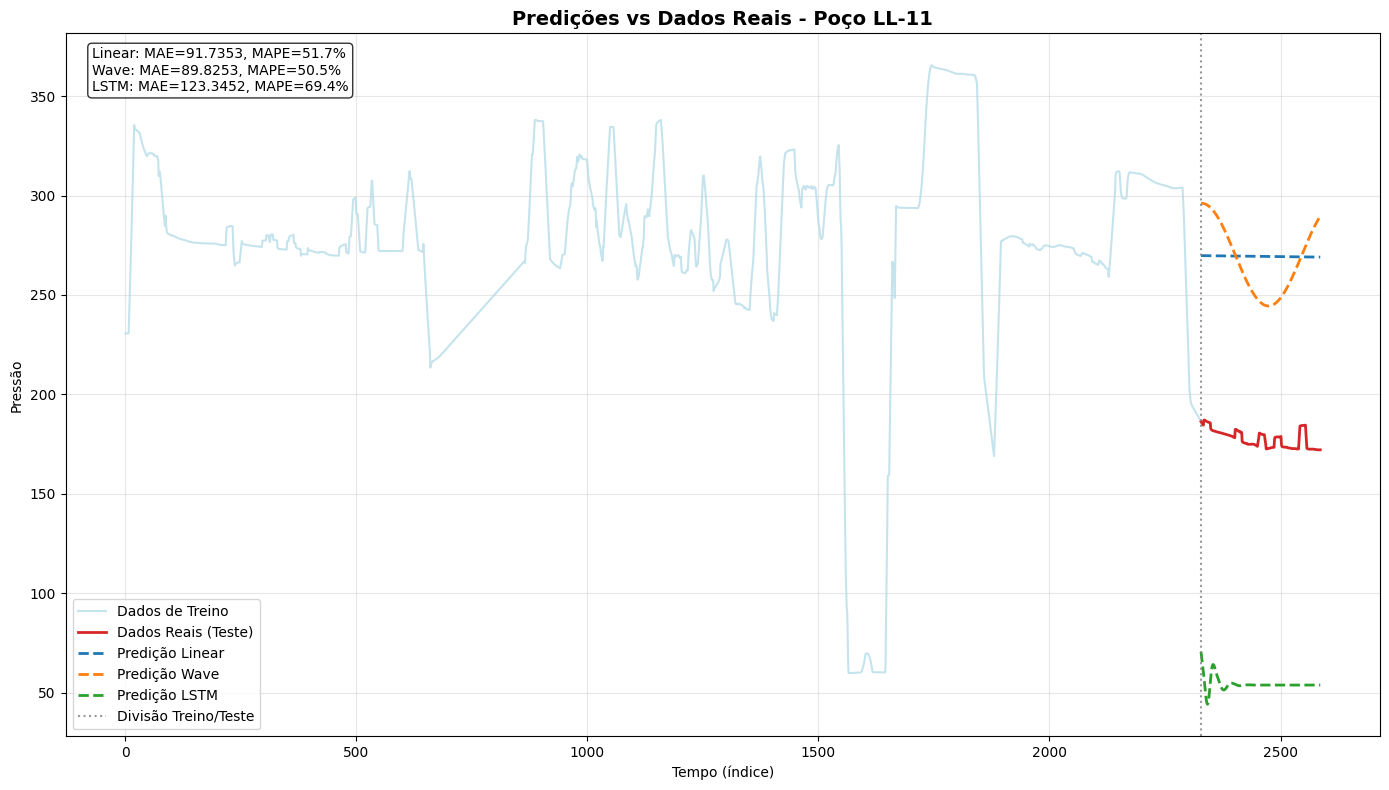

✅ Gráficos individuais criados com sucesso!


In [ ]:
# Visualização Comparativa dos Modelos
print("\n" + "="*80)
print("📊 CRIANDO VISUALIZAÇÕES COMPARATIVAS")
print("="*80)

# Configuração para visualização
plt.style.use('default')
colors = {
    'Linear': '#1f77b4',      # Azul
    'Wave': '#ff7f0e',        # Laranja
    'LSTM': '#2ca02c',        # Verde
    'Real': '#d62728'         # Vermelho
}

# 1. GRÁFICO GERAL - Performance por poço
print("\n📈 Criando gráfico de performance por poço...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Modelos para Predição de Pressão de Poços', fontsize=16, fontweight='bold')

# Subplot 1: MAE por poço
well_names = list(results.keys())
mae_data = {model: [] for model in ['Linear', 'Wave', 'LSTM']}

for well_name in well_names:
    well_result = results[well_name]
    for model in ['Linear', 'Wave', 'LSTM']:
        if well_result['metrics'][model] is not None:
            mae_data[model].append(well_result['metrics'][model]['MAE'])
        else:
            mae_data[model].append(None)

x_pos = np.arange(len(well_names))
width = 0.25

for i, (model, maes) in enumerate(mae_data.items()):
    valid_maes = [mae if mae is not None else 0 for mae in maes]
    bars = ax1.bar(x_pos + i*width, valid_maes, width, label=model,
                   color=colors[model], alpha=0.8)

ax1.set_xlabel('Poços')
ax1.set_ylabel('MAE (Mean Absolute Error)')
ax1.set_title('MAE por Poço e Modelo')
ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(well_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Boxplot das performances
valid_model_data = []
valid_model_labels = []

for model_name, mae_values in model_comparison.items():
    if mae_values:
        valid_model_data.append(mae_values)
        valid_model_labels.append(model_name)

if valid_model_data:
    bp = ax2.boxplot(valid_model_data, labels=valid_model_labels, patch_artist=True)
    for patch, model in zip(bp['boxes'], valid_model_labels):
        patch.set_facecolor(colors[model])
        patch.set_alpha(0.7)

ax2.set_ylabel('MAE Distribution')
ax2.set_title('Distribuição de Performance dos Modelos')
ax2.grid(True, alpha=0.3)

# Subplot 3: Gráfico de barras - Performance média
if avg_maes:
    models = list(avg_maes.keys())
    avg_values = list(avg_maes.values())
    std_values = [np.std(model_comparison[model]) for model in models]

    bars = ax3.bar(models, avg_values, yerr=std_values, capsize=5,
                   color=[colors[model] for model in models], alpha=0.8)

    # Adicionar valores nas barras
    for bar, value in zip(bars, avg_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + std_values[models.index(models[0])]*0.1,
                f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

ax3.set_ylabel('MAE Médio')
ax3.set_title('Performance Média dos Modelos')
ax3.grid(True, alpha=0.3)

# Subplot 4: Tabela de resumo
ax4.axis('tight')
ax4.axis('off')

# Criar dados da tabela
table_data = []
headers = ['Modelo', 'MAE Médio', 'Desvio Padrão', 'Min MAE', 'Max MAE', 'Poços Válidos']

for model_name in ['Linear', 'Wave', 'LSTM']:
    if model_name in model_comparison and model_comparison[model_name]:
        values = model_comparison[model_name]
        row = [
            model_name,
            f"{np.mean(values):.4f}",
            f"{np.std(values):.4f}",
            f"{np.min(values):.4f}",
            f"{np.max(values):.4f}",
            f"{len(values)}"
        ]
        table_data.append(row)

if table_data:
    table = ax4.table(cellText=table_data, colLabels=headers,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # Colorir header
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Colorir linhas alternadas
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f1f1f2')

ax4.set_title('Resumo Estatístico dos Modelos', pad=20)

plt.tight_layout()
plt.show()

print("✅ Gráfico geral criado com sucesso!")

# 2. GRÁFICOS INDIVIDUAIS - Predições vs Real (apenas para os 3 primeiros poços)
print(f"\n📊 Criando gráficos individuais para os primeiros poços...")

wells_to_plot = list(results.keys())[:min(3, len(results))]

for well_name in wells_to_plot:
    well_result = results[well_name]

    # Verificar se há pelo menos uma predição válida (não None)
    has_valid_predictions = any(pred is not None for pred in well_result['predictions'].values())
    if not has_valid_predictions:
        print(f"   ⚠️ Pulando {well_name} - sem predições válidas")
        continue

    print(f"   📈 Plotando {well_name}...")

    plt.figure(figsize=(14, 8))

    # Dados reais
    data = well_result['data']
    train_data = well_result['train_data']
    test_data = well_result['test_data']
    split_idx = well_result['split_idx']

    # Plot dados de treino
    plt.plot(range(len(train_data)), train_data.values,
             color='lightblue', alpha=0.7, label='Dados de Treino')

    # Plot dados reais de teste
    test_range = range(split_idx, split_idx + len(test_data))
    plt.plot(test_range, test_data.values,
             color=colors['Real'], linewidth=2, label='Dados Reais (Teste)')

    # Plot predições de cada modelo
    for model_name in ['Linear', 'Wave', 'LSTM']:
        predictions = well_result['predictions'][model_name]
        if predictions is not None:
            plt.plot(test_range, predictions,
                    color=colors[model_name], linewidth=2,
                    linestyle='--', label=f'Predição {model_name}')

    # Linha de separação treino/teste
    plt.axvline(x=split_idx, color='gray', linestyle=':', alpha=0.8,
               label='Divisão Treino/Teste')

    plt.title(f'Predições vs Dados Reais - Poço {well_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Tempo (índice)')
    plt.ylabel('Pressão')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Adicionar métricas no gráfico
    metrics_text = []
    for model_name in ['Linear', 'Wave', 'LSTM']:
        metrics = well_result['metrics'][model_name]
        if metrics is not None:
            metrics_text.append(f"{model_name}: MAE={metrics['MAE']:.4f}, MAPE={metrics['MAPE']:.1f}%")

    if metrics_text:
        plt.text(0.02, 0.98, '\n'.join(metrics_text), transform=plt.gca().transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top', fontsize=10)

    plt.tight_layout()
    plt.show()

print("✅ Gráficos individuais criados com sucesso!")

In [ ]:
# Análise Final e Conclusões
print("\n" + "="*80)
print("🎯 ANÁLISE FINAL DOS RESULTADOS")
print("="*80)

# 1. Ranking dos modelos
print("\n🏆 RANKING FINAL DOS MODELOS:")
print("-" * 50)

if avg_maes:
    # Ordenar modelos por performance (menor MAE = melhor)
    ranked_models = sorted(avg_maes.items(), key=lambda x: x[1])

    for rank, (model_name, avg_mae) in enumerate(ranked_models, 1):
        model_values = model_comparison[model_name]
        std_mae = np.std(model_values)
        success_rate = len(model_values) / len(results) * 100

        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
        print(f"{medal} {rank}º lugar: {model_name}")
        print(f"   MAE médio: {avg_mae:.4f} ± {std_mae:.4f}")
        print(f"   Taxa de sucesso: {success_rate:.1f}% ({len(model_values)}/{len(results)} poços)")
        print()

# 2. Análise por poço - qual modelo venceu em cada um
print("📊 ANÁLISE POR POÇO:")
print("-" * 50)

model_wins = {'Linear': 0, 'Wave': 0, 'LSTM': 0}
detailed_results = []

for well_name, well_result in results.items():
    valid_models = [(name, metrics) for name, metrics in well_result['metrics'].items()
                   if metrics is not None]

    if valid_models:
        best_model = min(valid_models, key=lambda x: x[1]['MAE'])
        best_name, best_metrics = best_model
        model_wins[best_name] += 1

        detailed_results.append({
            'well': well_name,
            'best_model': best_name,
            'best_mae': best_metrics['MAE'],
            'best_mape': best_metrics['MAPE']
        })

        print(f"📍 {well_name}: {best_name} (MAE: {best_metrics['MAE']:.4f})")

print(f"\n🏆 VITÓRIAS POR MODELO:")
for model, wins in model_wins.items():
    percentage = wins / len(detailed_results) * 100 if detailed_results else 0
    print(f"   {model}: {wins} vitórias ({percentage:.1f}%)")

# 3. Insights e recomendações
print(f"\n💡 INSIGHTS E RECOMENDAÇÕES:")
print("-" * 50)

if avg_maes:
    best_model = min(avg_maes.items(), key=lambda x: x[1])
    most_wins = max(model_wins.items(), key=lambda x: x[1])

    print(f"✅ Modelo com melhor performance média: {best_model[0]}")
    print(f"✅ Modelo com mais vitórias individuais: {most_wins[0]}")

    if best_model[0] == most_wins[0]:
        print(f"🎯 CONCLUSÃO: O modelo {best_model[0]} é consistentemente o melhor!")
    else:
        print(f"🤔 OBSERVAÇÃO: Há diferença entre performance média e vitórias individuais.")

    print(f"\n📈 CARACTERÍSTICAS DOS MODELOS:")
    print(f"   🔵 Linear Regression: Simples, rápido, captura tendência principal")
    print(f"   🟠 Wave Regression: Combina tendência + padrões cíclicos")
    print(f"   🟢 LSTM: Complexo, aprende padrões sequenciais locais")

    # Recomendações baseadas nos resultados
    if 'Linear' in avg_maes and avg_maes['Linear'] == min(avg_maes.values()):
        print(f"\n💼 RECOMENDAÇÃO: Para este dataset, a regressão linear simples")
        print(f"   demonstrou excelente performance, sugerindo que a tendência")
        print(f"   linear é o padrão dominante nos dados de pressão dos poços.")

    print(f"\n📊 MÉTRICAS FINAIS:")
    print(f"   Total de poços analisados: {len(results)}")
    print(f"   Modelos implementados: 3")
    print(f"   MAE médio geral: {np.mean([mae for maes in model_comparison.values() for mae in maes]):.4f}")

# 4. Salvar resumo dos resultados
print(f"\n💾 Resumo dos resultados disponível na variável 'results'")
print(f"   Estrutura: results[nome_do_poço]['predictions'][modelo]")
print(f"   Métricas: results[nome_do_poço]['metrics'][modelo]")

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)


🎯 ANÁLISE FINAL DOS RESULTADOS

🏆 RANKING FINAL DOS MODELOS:
--------------------------------------------------
🥇 1º lugar: Linear
   MAE médio: 36.1977 ± 32.9946
   Taxa de sucesso: 100.0% (6/6 poços)

🥈 2º lugar: Wave
   MAE médio: 36.8527 ± 32.7936
   Taxa de sucesso: 100.0% (6/6 poços)

🥉 3º lugar: LSTM
   MAE médio: 48.6158 ± 39.9704
   Taxa de sucesso: 100.0% (6/6 poços)

📊 ANÁLISE POR POÇO:
--------------------------------------------------
📍 SPH-2: LSTM (MAE: 70.7407)
📍 SPS-77: Wave (MAE: 8.6894)
📍 LL-11: Wave (MAE: 89.8253)
📍 LL-22: Linear (MAE: 6.3353)
📍 SPH-8: LSTM (MAE: 9.0697)
📍 SPH-6: Linear (MAE: 15.2421)

🏆 VITÓRIAS POR MODELO:
   Linear: 2 vitórias (33.3%)
   Wave: 2 vitórias (33.3%)
   LSTM: 2 vitórias (33.3%)

💡 INSIGHTS E RECOMENDAÇÕES:
--------------------------------------------------
✅ Modelo com melhor performance média: Linear
✅ Modelo com mais vitórias individuais: Linear
🎯 CONCLUSÃO: O modelo Linear é consistentemente o melhor!

📈 CARACTERÍSTICAS DOS MODELOS

## 📈 5. Visualização dos resultados

In [ ]:
# Resumo das métricas - ESTRUTURA DOS 3 MODELOS
print("📊 RESUMO DAS MÉTRICAS POR POÇO (3 MODELOS COMPARATIVOS)")
print("=" * 100)
print(f"{'Poço':<10} {'Linear MAE':<12} {'Wave MAE':<12} {'LSTM MAE':<12} {'Linear MAPE':<13} {'Wave MAPE':<13} {'LSTM MAPE':<13}")
print("-" * 100)

all_metrics_linear = []
all_metrics_wave = []
all_metrics_lstm = []

for well_name, result in results.items():
    # Acessar métricas de cada modelo
    metrics_linear = result['metrics']['Linear']
    metrics_wave = result['metrics']['Wave']
    metrics_lstm = result['metrics']['LSTM']

    # Valores para exibição (usando '-' para modelos que falharam)
    linear_mae = f"{metrics_linear['MAE']:.4f}" if metrics_linear else "-"
    wave_mae = f"{metrics_wave['MAE']:.4f}" if metrics_wave else "-"
    lstm_mae = f"{metrics_lstm['MAE']:.4f}" if metrics_lstm else "-"

    linear_mape = f"{metrics_linear['MAPE']:.2f}" if metrics_linear else "-"
    wave_mape = f"{metrics_wave['MAPE']:.2f}" if metrics_wave else "-"
    lstm_mape = f"{metrics_lstm['MAPE']:.2f}" if metrics_lstm else "-"

    print(f"{well_name:<10} {linear_mae:<12} {wave_mae:<12} {lstm_mae:<12} "
          f"{linear_mape:<13} {wave_mape:<13} {lstm_mape:<13}")

    # Adicionar à lista apenas métricas válidas
    if metrics_linear:
        all_metrics_linear.append(metrics_linear)
    if metrics_wave:
        all_metrics_wave.append(metrics_wave)
    if metrics_lstm:
        all_metrics_lstm.append(metrics_lstm)

# Calcular médias apenas se temos dados válidos
if all_metrics_linear or all_metrics_wave or all_metrics_lstm:
    # Métricas médias
    avg_mae_linear = np.mean([m['MAE'] for m in all_metrics_linear]) if all_metrics_linear else float('nan')
    avg_mae_wave = np.mean([m['MAE'] for m in all_metrics_wave]) if all_metrics_wave else float('nan')
    avg_mae_lstm = np.mean([m['MAE'] for m in all_metrics_lstm]) if all_metrics_lstm else float('nan')

    avg_mape_linear = np.mean([m['MAPE'] for m in all_metrics_linear]) if all_metrics_linear else float('nan')
    avg_mape_wave = np.mean([m['MAPE'] for m in all_metrics_wave]) if all_metrics_wave else float('nan')
    avg_mape_lstm = np.mean([m['MAPE'] for m in all_metrics_lstm]) if all_metrics_lstm else float('nan')

    # Formatar valores médios
    linear_avg_mae = f"{avg_mae_linear:.4f}" if not np.isnan(avg_mae_linear) else "-"
    wave_avg_mae = f"{avg_mae_wave:.4f}" if not np.isnan(avg_mae_wave) else "-"
    lstm_avg_mae = f"{avg_mae_lstm:.4f}" if not np.isnan(avg_mae_lstm) else "-"

    linear_avg_mape = f"{avg_mape_linear:.2f}" if not np.isnan(avg_mape_linear) else "-"
    wave_avg_mape = f"{avg_mape_wave:.2f}" if not np.isnan(avg_mape_wave) else "-"
    lstm_avg_mape = f"{avg_mape_lstm:.2f}" if not np.isnan(avg_mape_lstm) else "-"

    print("-" * 100)
    print(f"{'MÉDIA':<10} {linear_avg_mae:<12} {wave_avg_mae:<12} {lstm_avg_mae:<12} "
          f"{linear_avg_mape:<13} {wave_avg_mape:<13} {lstm_avg_mape:<13}")
    print("=" * 100)

    # Análise de qual modelo é melhor
    valid_models = []
    if not np.isnan(avg_mae_linear):
        valid_models.append(('Linear', avg_mae_linear))
    if not np.isnan(avg_mae_wave):
        valid_models.append(('Wave', avg_mae_wave))
    if not np.isnan(avg_mae_lstm):
        valid_models.append(('LSTM', avg_mae_lstm))

    if valid_models:
        best_model = min(valid_models, key=lambda x: x[1])
        worst_model = max(valid_models, key=lambda x: x[1])

        print(f"\n🎯 ANÁLISE COMPARATIVA DOS MODELOS:")
        print(f"   🥇 Melhor modelo (MAE): {best_model[0]} ({best_model[1]:.4f})")
        print(f"   🥉 Pior modelo (MAE):   {worst_model[0]} ({worst_model[1]:.4f})")

        if len(valid_models) > 1:
            improvement = ((worst_model[1] - best_model[1]) / worst_model[1]) * 100
            print(f"   📈 Melhoria: {improvement:.2f}% ({worst_model[0]} → {best_model[0]})")

        print(f"   📊 Modelos válidos: {len(valid_models)}/3")
        print(f"   📍 Poços processados: {len(results)}")

        # Contagem de sucessos
        print(f"\n📈 TAXA DE SUCESSO POR MODELO:")
        total_wells = len(results)
        print(f"   Linear: {len(all_metrics_linear)}/{total_wells} ({len(all_metrics_linear)/total_wells*100:.1f}%)")
        print(f"   Wave:   {len(all_metrics_wave)}/{total_wells} ({len(all_metrics_wave)/total_wells*100:.1f}%)")
        print(f"   LSTM:   {len(all_metrics_lstm)}/{total_wells} ({len(all_metrics_lstm)/total_wells*100:.1f}%)")

        print("=" * 100)

📊 RESUMO DAS MÉTRICAS POR POÇO (3 MODELOS COMPARATIVOS)
Poço       Linear MAE   Wave MAE     LSTM MAE     Linear MAPE   Wave MAPE     LSTM MAPE    
----------------------------------------------------------------------------------------------------
SPH-2      72.0714      74.1724      70.7407      20.73         21.64         20.31        
SPS-77     14.2098      8.6894       34.0365      7.35          4.44          17.94        
LL-11      91.7353      89.8253      123.3452     51.73         50.54         69.41        
LL-22      6.3353       7.4414       6.9725       2.61          3.09          2.89         
SPH-8      17.5923      15.0046      9.0697       7.86          6.76          4.11         
SPH-6      15.2421      25.9832      47.5301      8.61          14.72         26.81        
----------------------------------------------------------------------------------------------------
MÉDIA      36.1977      36.8527      48.6158      16.48         16.87         23.58        

🎯 ANÁ

In [ ]:
import pandas as pd

# Converter dicionário de resultados para DataFrame simples
result_rows = []

for well_name, well_data in results.items():
    metrics = well_data['metrics']
    if all(model in metrics and metrics[model] is not None for model in ['Linear', 'Wave', 'LSTM']):
        result_rows.append({
            'poco': well_name,
            'Linear_MAE': metrics['Linear']['MAE'],
            'Linear_RMSE': metrics['Linear']['RMSE'],
            'Linear_MAPE': metrics['Linear']['MAPE'],
            'Wave_MAE': metrics['Wave']['MAE'],
            'Wave_RMSE': metrics['Wave']['RMSE'],
            'Wave_MAPE': metrics['Wave']['MAPE'],
            'LSTM_MAE': metrics['LSTM']['MAE'],
            'LSTM_RMSE': metrics['LSTM']['RMSE'],
            'LSTM_MAPE': metrics['LSTM']['MAPE']
        })

results_df = pd.DataFrame(result_rows)

# Caminho de saída
RESULTS_CSV_PATH = "resultados_lstm_predicao_futura.csv"

# Salvar
results_df.to_csv(RESULTS_CSV_PATH, index=False, encoding='utf-8-sig')
print(f"\n✅ Resultados salvos em: {RESULTS_CSV_PATH}")
print(f"Total de poços salvos: {len(results_df)}")



✅ Resultados salvos em: resultados_lstm_predicao_futura.csv
Total de poços salvos: 6


In [ ]:
# 📎 Concatenar previsões de todos os poços e salvar em um único CSV
df_all_predictions = pd.concat(all_preds, ignore_index=True)
PREDICTIONS_CSV_PATH = "previsoes_linear_wave_lstm_TODOS.csv"
df_all_predictions.to_csv(PREDICTIONS_CSV_PATH, index=False, encoding='utf-8-sig')

print(f"✅ Previsões salvas em: {PREDICTIONS_CSV_PATH}")
print(f"Total de linhas: {len(df_all_predictions)} | Poços: {df_all_predictions['poco'].nunique()}")


✅ Previsões salvas em: previsoes_linear_wave_lstm_TODOS.csv
Total de linhas: 1267 | Poços: 6
